In [1]:
import pandas as pd
import numpy as np 
import sklearn 

print("Environment Ready")

Environment Ready


In [2]:
import pandas as pd

data = pd.read_csv("../Dataset/spam.csv", encoding="latin-1")


In [3]:
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
data.shape

(5572, 5)

In [5]:
data.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
data["v1"].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

<Axes: xlabel='v1'>

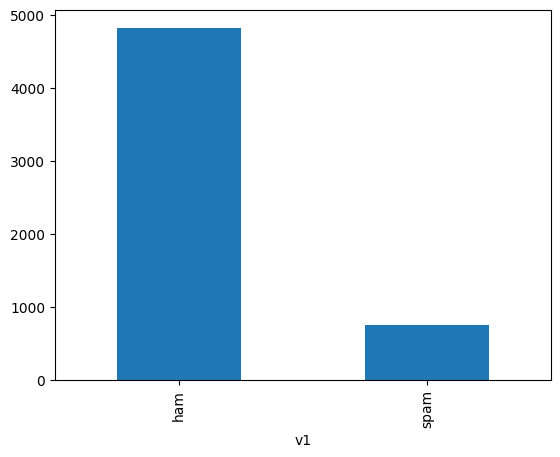

In [8]:
data["v1"].value_counts().plot(kind="bar")

In [9]:
data = data[["v1","v2"]]
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
data.columns = ['label', 'message']
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
data['label'] = data['label'].map({'ham':0, 'spam':1})
data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
data['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

In [13]:
data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
data['messgae'] = data['message'].str.lower()
data.head()

,label,message,messgae
0,0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,0,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


In [15]:
import re

data['message'] = data['message'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))
data.head()

,label,message,messgae
0,0,Go until jurong point crazy Available only in ...,"go until jurong point, crazy.. available only ..."
1,0,Ok lar Joking wif u oni,ok lar... joking wif u oni...
2,1,Free entry in a wkly comp to win FA Cup final...,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor U c already then say,u dun say so early hor... u c already then say...
4,0,Nah I dont think he goes to usf he lives aroun...,"nah i don't think he goes to usf, he lives aro..."


In [16]:
import re 

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

In [17]:
data['message'] = data['message'].apply(clean_text)
data.head()

,label,message,messgae
0,0,go until jurong point crazy available only in ...,"go until jurong point, crazy.. available only ..."
1,0,ok lar joking wif u oni,ok lar... joking wif u oni...
2,1,free entry in a wkly comp to win fa cup final...,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say,u dun say so early hor... u c already then say...
4,0,nah i dont think he goes to usf he lives aroun...,"nah i don't think he goes to usf, he lives aro..."


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [19]:
tfidf = TfidfVectorizer

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()


In [21]:
X = tfidf.fit_transform(data['message'])

In [22]:
y = data['label']

In [23]:
X.shape

(5572, 8512)

In [24]:
from sklearn.model_selection import train_test_split

X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [25]:
from sklearn.naive_bayes import MultinomialNB

In [26]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [27]:
y_pred = model.predict(x_test)

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.947085201793722


In [29]:
def predict_message(msg):
    #clean the message
    msg_clean = clean_text(msg)

    #convert to vector
    vector = tfidf.transform([msg_clean])

    #predict
    result = model.predict(vector)

    if result[0] == 1:
        return "spam"
    else:
        return "Not spam"
    


In [30]:
print(predict_message("Win ₹5000 now!!!"))
print(predict_message("Hey! how are you"))

Not spam
Not spam


In [31]:
print(clean_text("Win ₹5000 now!!!"))

win  now


In [32]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # keep numbers
    return text

In [33]:
print(predict_message("free entry win cash prize now"))

spam


In [35]:
import pickle

pickle.dump(model, open('../model/spam_model.pkl','wb'))
pickle.dump(tfidf, open('../model/tfidf.pkl','wb'))